In [ ]:
# Link do Live Share: https://prod.liveshare.vsengsaas.visualstudio.com/join?D752A593F4C394D5284A88E41FCFBAAE96B5

In [9]:
%pip install numpy
%pip install pandas
%pip install librosa
%pip install matplotlib
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Tomek\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Tomek\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\Tomek\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\Tomek\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [10]:
import numpy as np
import pandas as pd
import os
import librosa
import IPython.display as ipd

import matplotlib.pyplot as plt
import librosa.display

In [2]:
print(os.listdir('/kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-valid-dev'))

['cv-valid-dev']


In [3]:
filenames = pd.read_csv('/kaggle/input/datasets/mogebycavailable/dataset-part-1/common-voice.csv', sep=',')['filename']
filenames

0         cv-valid-dev/sample-000004.mp3
1         cv-valid-dev/sample-000005.mp3
2         cv-valid-dev/sample-000008.mp3
3         cv-valid-dev/sample-000009.mp3
4         cv-valid-dev/sample-000013.mp3
                       ...              
124915      cv-invalid/sample-025367.mp3
124916      cv-invalid/sample-025369.mp3
124917      cv-invalid/sample-025373.mp3
124918      cv-invalid/sample-025380.mp3
124919      cv-invalid/sample-025386.mp3
Name: filename, Length: 124920, dtype: object

In [ ]:
base_path = '/kaggle/input/datasets/organizations/mozillaorg/common-voice'

mel_coef = pd.DataFrame()

for filename in filenames:
    before, after = filename.rsplit('/', 1)
    path = base_path + '/' + before + '/' + before + '/' + after
    x , sr = librosa.load(path)
    
    mfccs = librosa.feature.mfcc(y=x, sr=sr)

    plt.figure(figsize=(15, 7))
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')

/tmp/ipykernel_55/3914376712.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(15, 7))


In [46]:
ipd.Audio(audio_data)

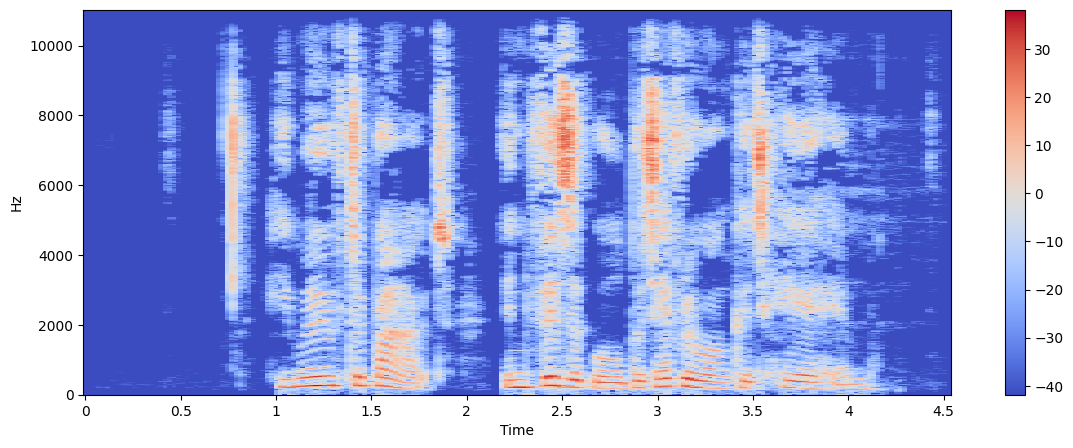

In [47]:
X = librosa.stft(x)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize=(14, 5))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()

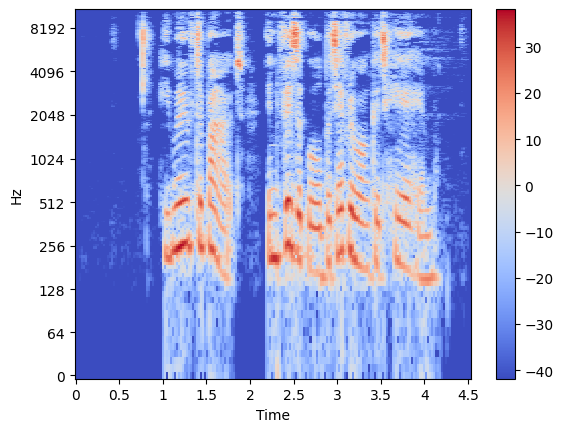

In [48]:
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()

(20, 196)
[[-6.1900824e+02 -6.1900824e+02 -6.1787543e+02 ... -5.9311517e+02
  -6.0950092e+02 -6.1895129e+02]
 [ 0.0000000e+00  0.0000000e+00  1.5716195e+00 ... -4.4729919e+00
   3.7145030e+00  7.8249201e-02]
 [ 0.0000000e+00  0.0000000e+00  1.4821990e+00 ...  2.0643772e+01
   7.8766303e+00  7.1487024e-02]
 ...
 [ 0.0000000e+00  0.0000000e+00 -1.2180970e+00 ... -5.8511333e+00
  -4.3894382e+00 -4.7759853e-02]
 [ 0.0000000e+00  0.0000000e+00 -1.2026794e+00 ...  1.0840398e+00
   1.5006807e+00 -3.1368159e-02]
 [ 0.0000000e+00  0.0000000e+00 -1.1573737e+00 ...  6.3161075e-01
   1.4927945e+00 -1.3261383e-02]]


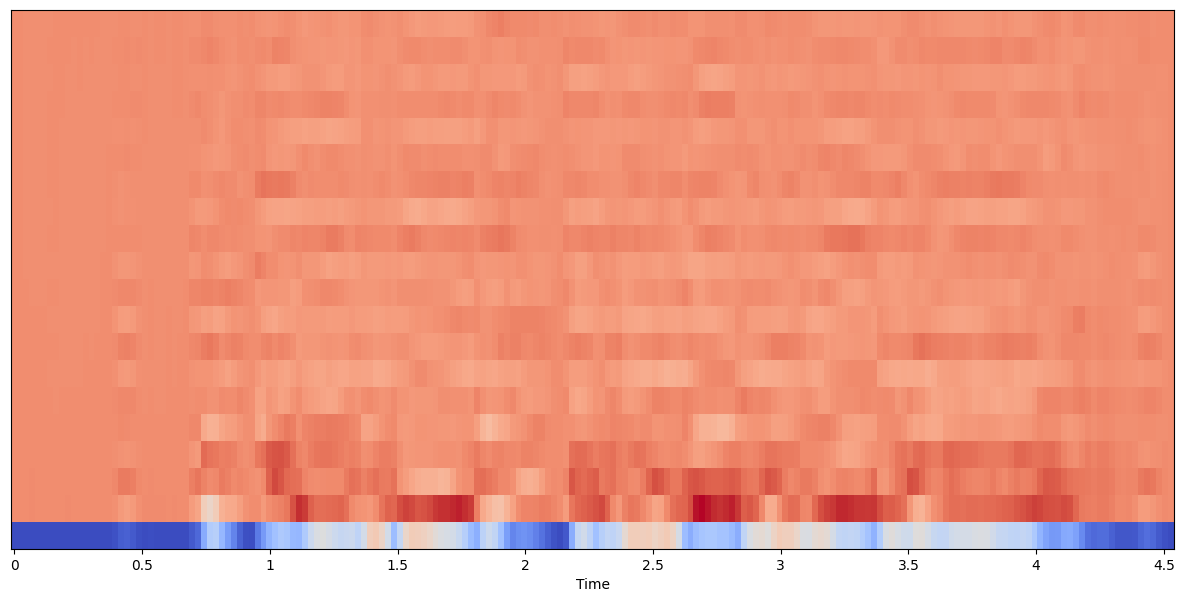

In [51]:
mfccs = librosa.feature.mfcc(y=x, sr=sr) 
                             # mozna dodac jeszcze liczbę współczynników MFCC, standardowo to n_mfcc=20

print(mfccs.shape)
print(mfccs)

#Displaying  the MFCCs:
plt.figure(figsize=(15, 7))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')

In [54]:
df = pd.DataFrame(mfccs)
df.to_csv('/kaggle/working/mfccs.csv', index=False)

In [ ]:
# Dane do CNN